In [1]:
import os
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from tensorflow.keras.utils import to_categorical

sns.set(style="whitegrid")

In [2]:
BASE_PATH = Path(r"E:\Thesis")

HAM_PATH = BASE_PATH / "HAM10000"
PAD_PATH = BASE_PATH / "PAD-UFES-20"

PAD_IMAGE_DIR = PAD_PATH / "images"

MODEL_DIR = BASE_PATH / "outputs" / "densenet201_baseline"
MODEL_PATH = MODEL_DIR / "best_model.keras"

OUT_DIR = BASE_PATH / "PAD_CLAHE_IMPROVED"
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (250, 250)
BATCH_SIZE = 4
CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]

print("Model path:", MODEL_PATH)
print("Output folder:", OUT_DIR)
print("PAD path exists:", PAD_PATH.exists())
print("PAD image dir exists:", PAD_IMAGE_DIR.exists())

Model path: E:\Thesis\outputs\densenet201_baseline\best_model.keras
Output folder: E:\Thesis\PAD_CLAHE_IMPROVED
PAD path exists: True
PAD image dir exists: True


In [3]:
pad = pd.read_csv(PAD_PATH / "metadata.csv")

pad_4 = pad[pad["diagnostic"].isin(CLASS_NAMES)].copy()
pad_4["label"] = pad_4["diagnostic"]
pad_4["image_path"] = pad_4["img_id"].apply(lambda x: str(PAD_IMAGE_DIR / x))
pad_4 = pad_4[pad_4["image_path"].apply(os.path.exists)].copy()

print("PAD samples:", len(pad_4))
print(pad_4["label"].value_counts())

PAD samples: 1871
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [4]:
pad_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

pad_generator = pad_datagen.flow_from_dataframe(
    dataframe=pad_4,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("Original PAD samples:", pad_generator.samples)

Found 1871 validated image filenames belonging to 4 classes.
Original PAD samples: 1871


In [5]:
best_model = load_model(MODEL_PATH)
print("Best model loaded.")

Best model loaded.


In [6]:
def apply_clahe(image_path, out_path, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Apply CLAHE on the L channel in LAB color space.
    """
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        return False

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    out_rgb = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    out_bgr = cv2.cvtColor(out_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(out_path), out_bgr)
    return True

In [7]:
CLAHE_DIR = OUT_DIR / "PAD_CLAHE"
CLAHE_DIR.mkdir(parents=True, exist_ok=True)

saved = 0
for _, row in pad_4.iterrows():
    img_path = Path(row["image_path"])
    out_path = CLAHE_DIR / img_path.name

    if not out_path.exists():
        ok = apply_clahe(
            image_path=img_path,
            out_path=out_path,
            clip_limit=2.0,
            tile_grid_size=(8, 8)
        )
        if ok:
            saved += 1

print("New CLAHE images saved:", saved)
print("Total expected:", len(pad_4))

New CLAHE images saved: 1871
Total expected: 1871


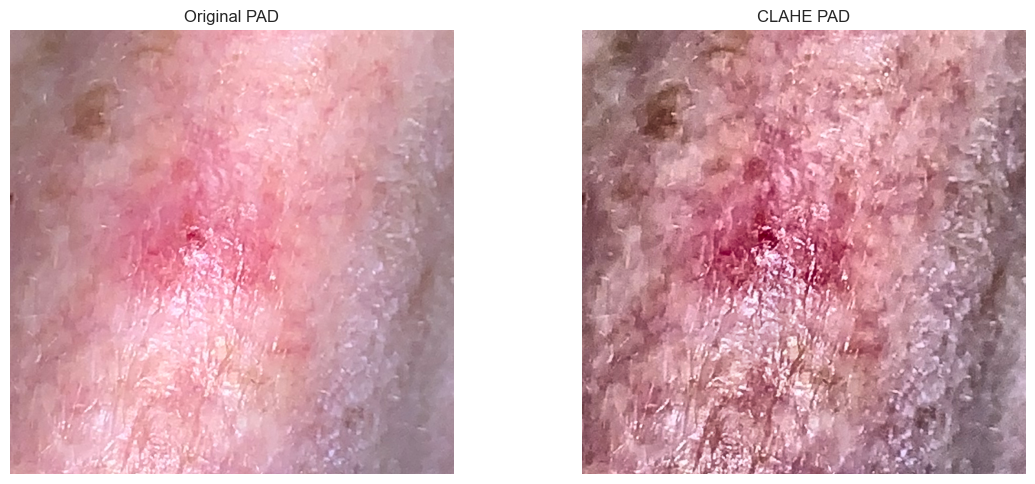

In [8]:
idx = 10 if len(pad_4) > 10 else 0

orig_path = Path(pad_4.iloc[idx]["image_path"])
clahe_path = CLAHE_DIR / orig_path.name

orig = cv2.cvtColor(cv2.imread(str(orig_path)), cv2.COLOR_BGR2RGB)
clahe_img = cv2.cvtColor(cv2.imread(str(clahe_path)), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(orig)
plt.title("Original PAD")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clahe_img)
plt.title("CLAHE PAD")
plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
pad_clahe_df = pad_4.copy()
pad_clahe_df["image_path"] = pad_clahe_df["img_id"].apply(lambda x: str(CLAHE_DIR / x))
pad_clahe_df["exists"] = pad_clahe_df["image_path"].apply(os.path.exists)

print("CLAHE exists:")
print(pad_clahe_df["exists"].value_counts())
print("CLAHE labels:")
print(pad_clahe_df["label"].value_counts())

CLAHE exists:
exists
True    1871
Name: count, dtype: int64
CLAHE labels:
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [10]:
pad_clahe_df = pad_clahe_df[pad_clahe_df["exists"]].copy()

pad_clahe_generator = pad_datagen.flow_from_dataframe(
    dataframe=pad_clahe_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("CLAHE samples:", pad_clahe_generator.samples)

Found 1871 validated image filenames belonging to 4 classes.
CLAHE samples: 1871


In [11]:
orig_loss, orig_acc = best_model.evaluate(pad_generator, verbose=1)
print("Original PAD Accuracy:", orig_acc)
print("Original PAD Loss:", orig_loss)

468/468 [==============================] - 187s 353ms/step - loss: 3.0001 - accuracy: 0.2892
Original PAD Accuracy: 0.2891501784324646
Original PAD Loss: 3.0000996589660645


In [12]:
clahe_loss, clahe_acc = best_model.evaluate(pad_clahe_generator, verbose=1)
print("CLAHE PAD Accuracy:", clahe_acc)
print("CLAHE PAD Loss:", clahe_loss)

468/468 [==============================] - 132s 281ms/step - loss: 2.8839 - accuracy: 0.2769
CLAHE PAD Accuracy: 0.27685728669166565
CLAHE PAD Loss: 2.8838753700256348


In [13]:
orig_probs = best_model.predict(pad_generator, verbose=1)
orig_preds = np.argmax(orig_probs, axis=1)
orig_true = pad_generator.classes

clahe_probs = best_model.predict(pad_clahe_generator, verbose=1)
clahe_preds = np.argmax(clahe_probs, axis=1)
clahe_true = pad_clahe_generator.classes

468/468 [==============================] - 102s 216ms/step


In [14]:
def compute_metrics(true_classes, pred_classes, pred_probs, class_names):
    acc = accuracy_score(true_classes, pred_classes)
    prec = precision_score(true_classes, pred_classes, average="macro", zero_division=0)
    rec = recall_score(true_classes, pred_classes, average="macro", zero_division=0)
    f1 = f1_score(true_classes, pred_classes, average="macro", zero_division=0)

    true_onehot = to_categorical(true_classes, num_classes=len(class_names))
    auc = roc_auc_score(
        true_onehot,
        pred_probs,
        multi_class="ovr",
        average="macro"
    )

    report = classification_report(
        true_classes,
        pred_classes,
        target_names=class_names,
        zero_division=0
    )

    cm = confusion_matrix(true_classes, pred_classes)
    return acc, prec, rec, f1, auc, report, cm

In [15]:
orig_acc_m, orig_prec, orig_rec, orig_f1, orig_auc, orig_report, orig_cm = compute_metrics(
    orig_true, orig_preds, orig_probs, CLASS_NAMES
)

print("=== Original PAD ===")
print("Accuracy :", orig_acc_m)
print("Precision:", orig_prec)
print("Recall   :", orig_rec)
print("F1 Score :", orig_f1)
print("AUC      :", orig_auc)
print(orig_report)

=== Original PAD ===
Accuracy : 0.28915018706574025
Precision: 0.29792286744381263
Recall   : 0.34610476349299785
F1 Score : 0.21773694454600206
AUC      : 0.6664067795001829
              precision    recall  f1-score   support

         ACK       0.28      0.03      0.06       730
         BCC       0.68      0.34      0.45       845
         MEL       0.05      0.08      0.06        52
         NEV       0.18      0.94      0.30       244

    accuracy                           0.29      1871
   macro avg       0.30      0.35      0.22      1871
weighted avg       0.44      0.29      0.27      1871



In [16]:
clahe_acc_m, clahe_prec, clahe_rec, clahe_f1, clahe_auc, clahe_report, clahe_cm = compute_metrics(
    clahe_true, clahe_preds, clahe_probs, CLASS_NAMES
)

print("=== CLAHE PAD ===")
print("Accuracy :", clahe_acc_m)
print("Precision:", clahe_prec)
print("Recall   :", clahe_rec)
print("F1 Score :", clahe_f1)
print("AUC      :", clahe_auc)
print(clahe_report)

=== CLAHE PAD ===
Accuracy : 0.27685729556386957
Precision: 0.29356749703098906
Recall   : 0.35480568249315336
F1 Score : 0.21711367380130206
AUC      : 0.6613601280479868
              precision    recall  f1-score   support

         ACK       0.27      0.05      0.08       730
         BCC       0.68      0.29      0.41       845
         MEL       0.04      0.13      0.06        52
         NEV       0.19      0.95      0.32       244

    accuracy                           0.28      1871
   macro avg       0.29      0.35      0.22      1871
weighted avg       0.44      0.28      0.26      1871



In [17]:
comparison = pd.DataFrame({
    "Setting": ["Original PAD", "CLAHE PAD"],
    "Accuracy": [orig_acc_m, clahe_acc_m],
    "Macro Precision": [orig_prec, clahe_prec],
    "Macro Recall": [orig_rec, clahe_rec],
    "Macro F1": [orig_f1, clahe_f1],
    "Macro AUC": [orig_auc, clahe_auc]
})

comparison["Accuracy Gain"] = comparison["Accuracy"] - comparison.loc[0, "Accuracy"]
comparison["F1 Gain"] = comparison["Macro F1"] - comparison.loc[0, "Macro F1"]
comparison["AUC Gain"] = comparison["Macro AUC"] - comparison.loc[0, "Macro AUC"]

print(comparison)
comparison.to_csv(OUT_DIR / "comparison.csv", index=False)

        Setting  Accuracy  Macro Precision  Macro Recall  Macro F1  Macro AUC  \
0  Original PAD  0.289150         0.297923      0.346105  0.217737   0.666407   
1     CLAHE PAD  0.276857         0.293567      0.354806  0.217114   0.661360   

   Accuracy Gain   F1 Gain  AUC Gain  
0       0.000000  0.000000  0.000000  
1      -0.012293 -0.000623 -0.005047  


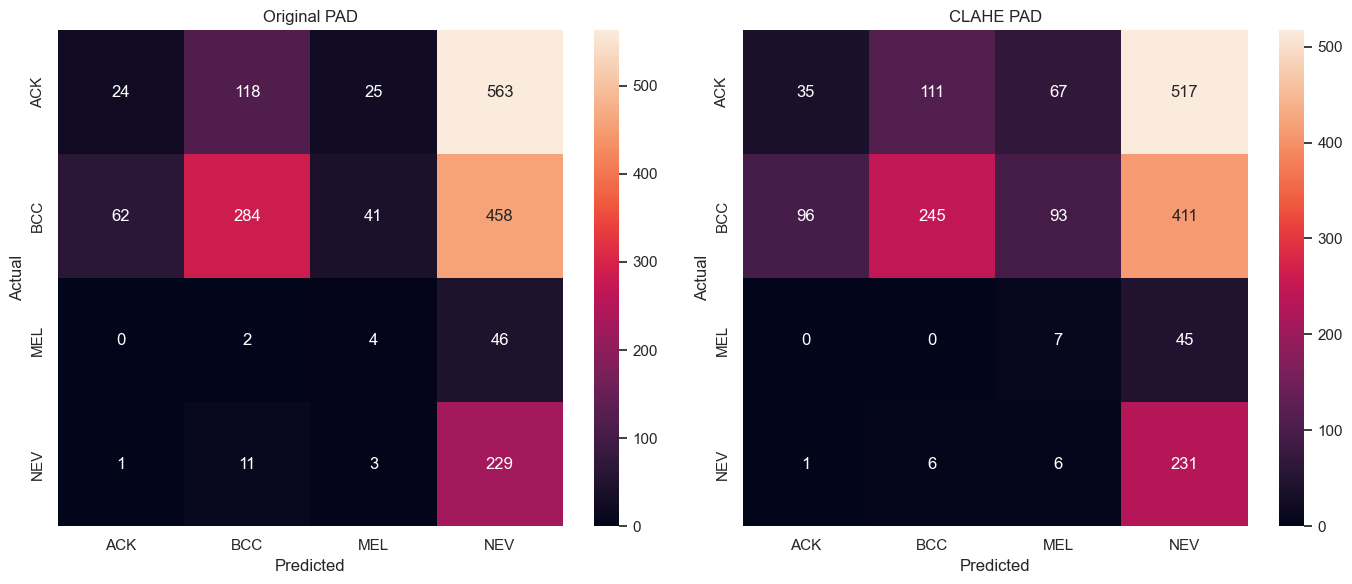

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(orig_cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Original PAD")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(clahe_cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("CLAHE PAD")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
results = {
    "original_pad": {
        "accuracy": float(orig_acc_m),
        "precision": float(orig_prec),
        "recall": float(orig_rec),
        "f1": float(orig_f1),
        "auc": float(orig_auc),
    },
    "clahe_pad": {
        "accuracy": float(clahe_acc_m),
        "precision": float(clahe_prec),
        "recall": float(clahe_rec),
        "f1": float(clahe_f1),
        "auc": float(clahe_auc),
    }
}

with open(OUT_DIR / "results.json", "w") as f:
    json.dump(results, f, indent=2)

pad_clahe_df[["img_id", "label", "image_path"]].to_csv(
    OUT_DIR / "clahe_pad_paths.csv",
    index=False
)

print("Saved results.json and clahe_pad_paths.csv")

Saved results.json and clahe_pad_paths.csv


In [20]:
print("\n--- CLAHE REPORT ---")
print(f"Original PAD F1: {orig_f1:.4f}")
print(f"CLAHE PAD F1: {clahe_f1:.4f}")
print(f"F1 Gain: {clahe_f1 - orig_f1:.4f}")
print(f"Original PAD AUC: {orig_auc:.4f}")
print(f"CLAHE PAD AUC: {clahe_auc:.4f}")


--- CLAHE REPORT ---
Original PAD F1: 0.2177
CLAHE PAD F1: 0.2171
F1 Gain: -0.0006
Original PAD AUC: 0.6664
CLAHE PAD AUC: 0.6614
